<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset Fashion MNIST utilizando modelos de classificação do sklearn.

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:
- correto
- reprodutível
- bem estruturado
- criticamente analisado

# Dicas importantes

## Sobre o dataset (Fashion MNIST)

- Utilize `fetch_openml` do sklearn para carregar os dados
- Use: `as_frame=False`
- Use: `mnist_784`
- Converta os rótulos para inteiro:
  
  ```python
  y = y.astype(int)
  ```

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `Fashion MNIST`
Realize a separação em treino e teste
Utilize `train_test_split` com controle de aleatoriedade
Retorne: `X_train`, `X_test`, `y_train`, `y_test`

Depois responda: 
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**:

In [3]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

def load_data(seed):

    X, y = fetch_openml('Fashion-MNIST', version=1, as_frame=False, return_X_y=True, parser='auto')
    
    y = y.astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    
    return X_train, X_test, y_train, y_test

Os modelos Random Forest e AdaBoost são algoritmos baseados em árvores de decisão. As árvores de decisão tomam decisões baseadas na ordenação dos valores (ex: "o pixel X é maior que 128?"). Elas não são sensíveis a escala ou absoluta dos dados.

Então não, não é necessário normalizar os dados.

# Questão 2

Implemente as funções:

`train_random_forest(X_train, y_train, seed)`
`train_adaboost(X_train, y_train, seed)`

## Requisitos:

Utilizar os modelos do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

In [4]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

def train_random_forest(X_train, y_train, seed, max_depth=None, n_estimators=100):
    rf_clf = RandomForestClassifier(
        random_state=seed, 
        max_depth=max_depth, 
        n_estimators=n_estimators, 
        n_jobs=-1
    )
    rf_clf.fit(X_train, y_train)
    return rf_clf

def train_adaboost(X_train, y_train, seed, max_depth=1, n_estimators=50):
    base_tree = DecisionTreeClassifier(max_depth=max_depth, random_state=seed)
    
    ada_clf = AdaBoostClassifier(
        estimator=base_tree, 
        random_state=seed, 
        n_estimators=n_estimators
    )
    ada_clf.fit(X_train, y_train)
    return ada_clf

# Questão 3

Implemente a função:

- `evaluate(model, X_test, y_test)`

Ela deve:
- Realizar predições
- Retornar a acurácia do modelo

**Solução**:

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(model, X_test, y_test):

    print(f"\nAvaliando modelo: {model.__class__.__name__}...")
    
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print(f"Acurácia:  {accuracy:.4f}")
    print(f"Precisão:  {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    return accuracy

**Adicione seu texto de solução aqui**.
Só pedia pra retornar a acurácia mas eu coloquei todas as métricas sendo printadas aqui para eu ter de onde tirar elas.

# Questão 4

Implemente a função:

- `run_pipeline(model_type="rf", seed=42)`

Ela deve:
- Carregar os dados
- Treinar o modelo escolhido (`rf` ou `ab`)
- Avaliar o modelo
- Retornar a acurácia

**Solução**:

In [6]:
def run_pipeline(model_type="rf", seed=42, analyze_overfitting=False, n_estimators=None):

    print(f"\n[{'='*60}]")
    print(f"Iniciando Pipeline | Modelo: {model_type.upper()} | Seed: {seed} | Estimadores: {n_estimators or 'Default'}")
    print(f"[{'='*60}]\n")

    X_train, X_test, y_train, y_test = load_data(seed)

    if analyze_overfitting:
        print(f">>> INICIANDO ANÁLISE DE OVERFITTING ({model_type.upper()}) <<<")
        depths = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, None] 

        for depth in depths:
            n_est = n_estimators if n_estimators is not None else (100 if model_type == "rf" else 50)

            if model_type == "rf":
                temp_model = train_random_forest(X_train, y_train, seed, max_depth=depth, n_estimators=n_est)
            else:
                temp_model = train_adaboost(X_train, y_train, seed, max_depth=depth, n_estimators=n_est)

            acc_train = accuracy_score(y_train, temp_model.predict(X_train))
            acc_test = accuracy_score(y_test, temp_model.predict(X_test))

            depth_str = "None (Máx)" if depth is None else f"{depth:02d}"
            print(f"Profundidade: {depth_str} | Acc Treino: {acc_train:.4f} | Acc Teste: {acc_test:.4f}")
            
        print(">>> FIM DA ANÁLISE <<<\n")
        return 

    if model_type == "rf":
        n_est = n_estimators if n_estimators is not None else 100
        model = train_random_forest(X_train, y_train, seed, n_estimators=n_est) 
    elif model_type == "ab":
        n_est = n_estimators if n_estimators is not None else 50
        model = train_adaboost(X_train, y_train, seed, n_estimators=n_est)

    accuracy = evaluate(model, X_test, y_test)

    return accuracy

**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

In [ ]:
# run_pipeline(model_type="rf", seed=42, analyze_overfitting=True)
# run_pipeline(model_type="ab", seed=42, analyze_overfitting=True)


[============================================================]
Iniciando Pipeline | Modelo: RF | Seed: 42 | Estimadores: Default
[============================================================]

>>> INICIANDO ANÁLISE DE OVERFITTING (RF) <<<
Profundidade: 01 | Acc Treino: 0.3199 | Acc Teste: 0.3124
Profundidade: 05 | Acc Treino: 0.7759 | Acc Teste: 0.7739
Profundidade: 10 | Acc Treino: 0.8822 | Acc Teste: 0.8539
Profundidade: 15 | Acc Treino: 0.9656 | Acc Teste: 0.8774
Profundidade: 20 | Acc Treino: 0.9930 | Acc Teste: 0.8824
Profundidade: 25 | Acc Treino: 0.9988 | Acc Teste: 0.8842
Profundidade: 30 | Acc Treino: 0.9999 | Acc Teste: 0.8843
Profundidade: 35 | Acc Treino: 1.0000 | Acc Teste: 0.8837
Profundidade: 40 | Acc Treino: 1.0000 | Acc Teste: 0.8843
Profundidade: 45 | Acc Treino: 1.0000 | Acc Teste: 0.8825
Profundidade: 50 | Acc Treino: 1.0000 | Acc Teste: 0.8824
Profundidade: None (Máx) | Acc Treino: 1.0000 | Acc Teste: 0.8824
>>> FIM DA ANÁLISE <<<


[==============================

RandomForest -> Overfitting exato na profundidade 35 que é quando atingimos 100% no treino mas a % de teste caiu.

AdaBoost -> Overfitting exato na profundidade 15 que é quanto atingimos 100% no treino mas a % de teste caiu.

Embora o AdaBoost tenha demorado muito para rodar por ter um treinamento sequencial (o que impossibilitou testar as profundidades extremas), os resultados mostram claramente que o overfitting começa a ficar severo a partir da profundidade 15 em ambos os modelos, ponto em que a acurácia de teste trava na casa dos 0.87/0.88 enquanto a de treino dispara rumo à perfeição. A árvore consegue cravar exatos 100% de acurácia no treino com max_depth=None (ou nas profundidades 15 para o AB e 35 para o RF) porque a ausência de um limite de crescimento permite que ela se ramifique até criar uma regra hiperespecífica para cada dado do dataset, ou seja, o modelo perde a capacidade de generalização e simplesmente decora o gabarito dos dados de treinamento.

# Questão 5

Execute o pipeline para ambos os modelos:

- Random Forest
- AdaBoost

## Apresente:
- Acurácia, Precisão, Recall e F1-Score de cada modelo

## Responda:
- Qual modelo apresentou melhor desempenho inicial?

**Solução**:

In [ ]:
# acuracia_rf_q5 = run_pipeline(model_type="rf", seed=42, analyze_overfitting=False)

# print("\n" + "-"*50 + "\n")

# acuracia_ab_q5 = run_pipeline(model_type="ab", seed=42, analyze_overfitting=False)


[============================================================]
Iniciando Pipeline | Modelo: RF | Seed: 42 | Estimadores: Default
[============================================================]


Avaliando modelo: RandomForestClassifier...
Acurácia:  0.8824
Precisão:  0.8812
Recall:    0.8825
F1-Score:  0.8807

--------------------------------------------------


[============================================================]
Iniciando Pipeline | Modelo: AB | Seed: 42 | Estimadores: Default
[============================================================]


Avaliando modelo: AdaBoostClassifier...
Acurácia:  0.5376
Precisão:  0.5361
Recall:    0.5344
F1-Score:  0.4861


O modelo que apresentou o melhor desempenho inicial foi, disparado, o Random Forest.

Com as configurações padrão, o Random Forest alcançou um desempenho robusto e equilibrado, com cerca de 88% em todas as métricas (Acurácia: 0.8824, F1-Score: 0.8807). 

Já o AdaBoost, tivemos um desempenho muito inferior, com acurácia na casa dos 53% e um F1-Score de apenas 48%.

O motivo dessa diferença é as configurações padrão (default) do sklearn pra cada algoritmo. O Random Forest, por padrão, não impõe limite de profundidade às suas árvores (max_depth=None), permitindo que o modelo capture padrões complexos nas imagens (combinações de múltiplos pixels). Já o AdaBoost, por padrão, utiliza Decision Stumps (árvores com profundidade 1) como estimadores base. Imagens de roupas com 784 pixels são complexas demais para serem classificadas por um modelo tão simples que faz apenas "uma pergunta" por vez. Para que o AdaBoost alcance o Random Forest nesse cenário visual, ele exigiria uma otimização pesada de hiperparâmetros (aumentando a profundidade da árvore base ou multiplicando drasticamente o número de estimadores).

# Questão 6

Execute o pipeline utilizando diferentes seeds (ex: 42 e 7).

## Analise:
- Os resultados mudaram?

Sim, os resultados sofreram alterações. Analisando as métricas, notamos que o Random Forest é um modelo bastante estável: sua acurácia variou muito pouco, caindo de 0.8824 (Seed 42) para 0.8795 (Seed 7). 

Por outro lado, o AdaBoost mostrou-se altamente sensível à mudança, com sua acurácia despencando de 0.5376 para 0.4799 (uma queda de quase 6%). Essas mudanças ocorrem porque alterar a seed muda o "ponto de partida" da aleatoriedade do pipeline. Isso afeta diretamente o train_test_split e a inicialização interna dos algoritmos.

## Responda:
- O experimento é reprodutível? Justifique.

Sim, o experimento é reprodutível.

Reprodutibilidade significa que o mesmo código, rodando sobre os mesmos dados, com a mesma semente aleatória, gerará matematicamente os mesmos resultados, todas as vezes.

Como o nosso pipeline foi construído repassando rigorosamente o parâmetro random_state desde a função load_data até a inicialização dos classificadores, nós garantimos o determinismo do código.

**Solução**:

In [ ]:
# print("=== AVALIAÇÃO COM SEED 42 ===")
# run_pipeline(model_type="rf", seed=42, analyze_overfitting=False)
# run_pipeline(model_type="ab", seed=42, analyze_overfitting=False)

# print("\n" + "#"*60 + "\n")

# print("=== AVALIAÇÃO COM SEED 7 ===")
# run_pipeline(model_type="rf", seed=7, analyze_overfitting=False)
# run_pipeline(model_type="ab", seed=7, analyze_overfitting=False)

=== AVALIAÇÃO COM SEED 42 ===

[============================================================]
Iniciando Pipeline | Modelo: RF | Seed: 42 | Estimadores: Default
[============================================================]


Avaliando modelo: RandomForestClassifier...
Acurácia:  0.8824
Precisão:  0.8812
Recall:    0.8825
F1-Score:  0.8807

[============================================================]
Iniciando Pipeline | Modelo: AB | Seed: 42 | Estimadores: Default
[============================================================]


Avaliando modelo: AdaBoostClassifier...
Acurácia:  0.5376
Precisão:  0.5361
Recall:    0.5344
F1-Score:  0.4861

############################################################

=== AVALIAÇÃO COM SEED 7 ===

[============================================================]
Iniciando Pipeline | Modelo: RF | Seed: 7 | Estimadores: Default
[============================================================]


Avaliando modelo: RandomForestClassifier...
Acurácia:  0.8795
Prec

0.4799285714285714

# Questão 7

Para pelo menos um dos modelos:

- Compare a acurácia em treino e teste

## Responda:

### - Existe overfitting?
Sim, existe um overfitting claro.

O overfitting é caracterizado por: o modelo deixa de extrair padrões gerais que se aplicam a dados novos (o que faz a acurácia de teste parar de crescer) e passa a memorizar os ruídos e peculiaridades dos dados que ele já tem em mãos (o que faz a acurácia de treino chegar à perfeição de 100%). 

Vemos isso acontecendo no RandomForest principalmente na profundidade 35 onde temos 100% de acurácia no Treino mas a acurácia do Teste caiu comparado a profundidade 30.

### - Qual modelo tende a sofrer mais com isso?
Considerando as configurações padrão do sklearn, o Random Forest tende a sofrer muito mais com o overfitting.

Como o Random Forest não impõe limite de profundidade por padrão (max_depth=None), suas árvores crescem até decorar perfeitamente cada amostra do treino, gerando essa grande lacuna entre o desempenho de treino e teste.

Em contraste, o AdaBoost clássico utiliza Decision Stumps (árvores de profundidade 1) como estimadores base. Por serem modelos tão simples, eles são fracos demais para conseguir decorar um dataset inteiro, tornando o AdaBoost padrão muito mais resistente ao overfitting por profundidade.

Análise das profundidades e acurácia já foi rodada acima.

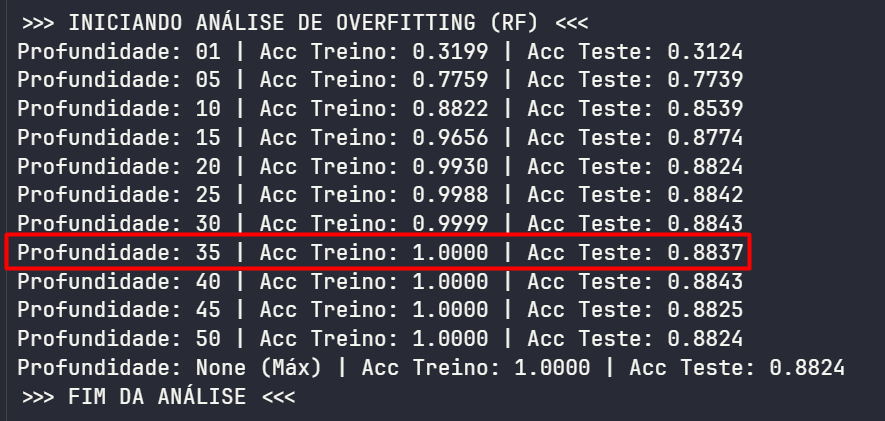

# Questão 8

Varie pelo menos um hiperparâmetro em cada modelo:

- Random Forest: `n_estimators`
- AdaBoost: `n_estimators`

## Analise:
### O desempenho muda significativamente?
No Random Forest, a mudança é muito sutil após um limiar inicial. Saltando de 10 para 50 estimadores, houve um pequeno ganho (de 86,2% para 88,0% de acurácia). No entanto, ao quadruplicar o número de árvores de 50 para 200, a acurácia subiu apenas 0,4% (chegando a 88,5%). Isso mostra que o desempenho rapidamente estabiliza e o custo computacional de adicionar mais árvores deixa de compensar.

Já no AdaBoost, a mudança é drástica e altamente significativa. Com apenas 10 estimadores, o modelo sofre de um underfitting severo (apenas 25,9% de acurácia). Ao aumentar para 200 estimadores, a acurácia salta para 58,8% e o F1-Score triplica (de 17,1% para 56,2%).

## Responda:
### Qual modelo é mais sensível a mudanças?
O AdaBoost provou ser infinitamente mais sensível a mudanças no parâmetro n_estimators.

O Random Forest constrói suas árvores de forma paralela e independente. A predição final é uma média (ou votação majoritária). Depois que há árvores suficientes para "diluir" a variância (geralmente em torno de 50 a 100), adicionar mais árvores não traz novas informações reais, apenas estabiliza a média estatística.

Por outro lado, o AdaBoost constrói árvores simples de forma sequencial, onde a árvore atual é treinada especificamente para corrigir os erros da árvore anterior. O número de estimadores dita quantas "chances de correção" o modelo terá. Por isso, ao passar de 10 para 200 iterações, demos ao AdaBoost o tempo necessário para refinar seus erros, justificando a enorme sensibilidade e a curva de aprendizado muito mais íngreme.

In [ ]:
# valores_estimadores = [10, 50, 100, 200]

# for n in valores_estimadores:
#     acc = run_pipeline(model_type="rf", seed=42, n_estimators=n, analyze_overfitting=False)

# print("\n" + "#"*60 + "\n")

# for n in valores_estimadores:
#     acc = run_pipeline(model_type="ab", seed=42, n_estimators=n, analyze_overfitting=False)


[============================================================]
Iniciando Pipeline | Modelo: RF | Seed: 42 | Estimadores: 10
[============================================================]


Avaliando modelo: RandomForestClassifier...
Acurácia:  0.8626
Precisão:  0.8611
Recall:    0.8626
F1-Score:  0.8601

[============================================================]
Iniciando Pipeline | Modelo: RF | Seed: 42 | Estimadores: 50
[============================================================]


Avaliando modelo: RandomForestClassifier...
Acurácia:  0.8806
Precisão:  0.8793
Recall:    0.8806
F1-Score:  0.8788

[============================================================]
Iniciando Pipeline | Modelo: RF | Seed: 42 | Estimadores: 100
[============================================================]


Avaliando modelo: RandomForestClassifier...
Acurácia:  0.8824
Precisão:  0.8812
Recall:    0.8825
F1-Score:  0.8807

[============================================================]
Iniciando Pipelin

# Questão 9

Responda (máx. 2 parágrafos por item):

## 1. A acurácia é suficiente para avaliar os modelos?
Não, a acurácia isolada raramente é suficiente, mesmo em datasets perfeitamente balanceados como o Fashion MNIST. Embora ela forneça uma boa visão geral do acerto global do modelo, ela mascara erros específicos e confusões entre classes visualmente semelhantes (por exemplo, o modelo pode ter facilidade em acertar sapatos, mas errar muito confundindo Shirt com T-shirt ou Pullover).

Para uma avaliação analítica robusta, métricas como Precisão e Recall são essenciais. O F1-Score, ao fazer a média harmônica dessas duas, oferece uma visão muito mais realista de quão bem o modelo realmente aprendeu a distinguir as nuances anatômicas de cada peça de roupa, em vez de apenas avaliar os acertos óbvios.

## 2. Como você garante que o resultado não ocorreu por acaso?

A principal garantia implementada no nosso pipeline foi o controle rigoroso da aleatoriedade através do parâmetro random_state (a seed) em absolutamente todas as etapas. Ao fixarmos a mesma semente desde a separação dos dados (train_test_split) até a inicialização dos estimadores internos dos algoritmos, garantimos o determinismo do experimento. 

Além disso, ao rodarmos o experimento com seeds diferentes (como na Questão 6), pudemos validar a estabilidade real dos modelos frente à variação inicial. O fato de o Random Forest ter mantido a sua performance na casa dos 88% independentemente da semente escolhida atesta que o modelo capturou padrões reais e consistentes dos dados, e não apenas decorou um conjunto específico de amostras.

## 3. Cite dois possíveis problemas metodológicos neste experimento.

O primeiro problema metodológico é a dependência de um único split de treino e teste. Como o dataset foi dividido apenas uma vez, a nossa avaliação fica totalmente refém daquela amostragem específica. O ideal seria utilizar a Validação Cruzada, que treina e avalia os modelos em múltiplas fatias alternadas dos dados, entregando uma métrica média muito mais confiável e à prova de viés de amostragem.

O segundo problema é a ausência de uma busca exaustiva e automatizada de hiperparâmetros. Neste experimento, nós variamos apenas a profundidade ou o número de estimadores manualmente e de forma isolada, o que ignora a interação complexa entre os parâmetros. Consequentemente, não podemos garantir que os modelos (especialmente o AdaBoost) atingiram sua perfeição de desempenho.

## 4. O pipeline implementado é confiável? Justifique.

Sim, o pipeline é confiável. Ele foi construído seguindo boas práticas: é modular, possui separação clara de responsabilidades (funções de carga, treino e avaliação), reaproveita código de forma limpa e foi desenhado desde o princípio para ser determinístico. 

No entanto, sob a ótica da Ciência de Dados para um ambiente de produção real, sua confiabilidade é apenas inicial. Embora cumpra com excelência o papel didático de comprovar conceitos teóricos (como overfitting e a importância de ensembles), para ser implantado em um cenário de negócios real ele exigiria as correções metodológicas citadas anteriormente (validação cruzada e otimização conjunta de hiperparâmetros) para atestar que o modelo possui, de fato, a melhor capacidade de generalização possível para dados inéditos.